In [3]:
using Revise
using Optics_in_the_length_gauge
using LinearAlgebra
using Parameters
using Field_Induced_Hall_Effect
using Brillouin
using Bravais
using CairoMakie, BZpaths

In [4]:
pathof(Optics_in_the_length_gauge)

"/Users/fernandopenaranda/.julia/packages/Optics_in_the_length_gauge/QbsqU/src/Optics_in_the_length_gauge.jl"

## Bands

In [5]:

function bands(q, p, i)
    mat = ferroaxial_ham3d(q,p.μ,p.Δ,p.t, p.tp)
    ϵs, ψs = eigen(mat)   
    return ϵs[i]
end

function bands_ferroaxial(p; a = 1)
    Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    # Rs = (a .* [3/2, √3/2, 0], a .* [-3/2, √3/2,0], a .* [0,0,1.0])  # Lattice vectors
    sgnum = 143                           # point group (144 = p3_1)
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "Δ = $(p.Δ) eV, t = $(p.t) eV, tp = $(p.tp) eV")
    for i in 1:2
        dispersion(q) = bands(q, p, i)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end

bands_ferroaxial (generic function with 1 method)

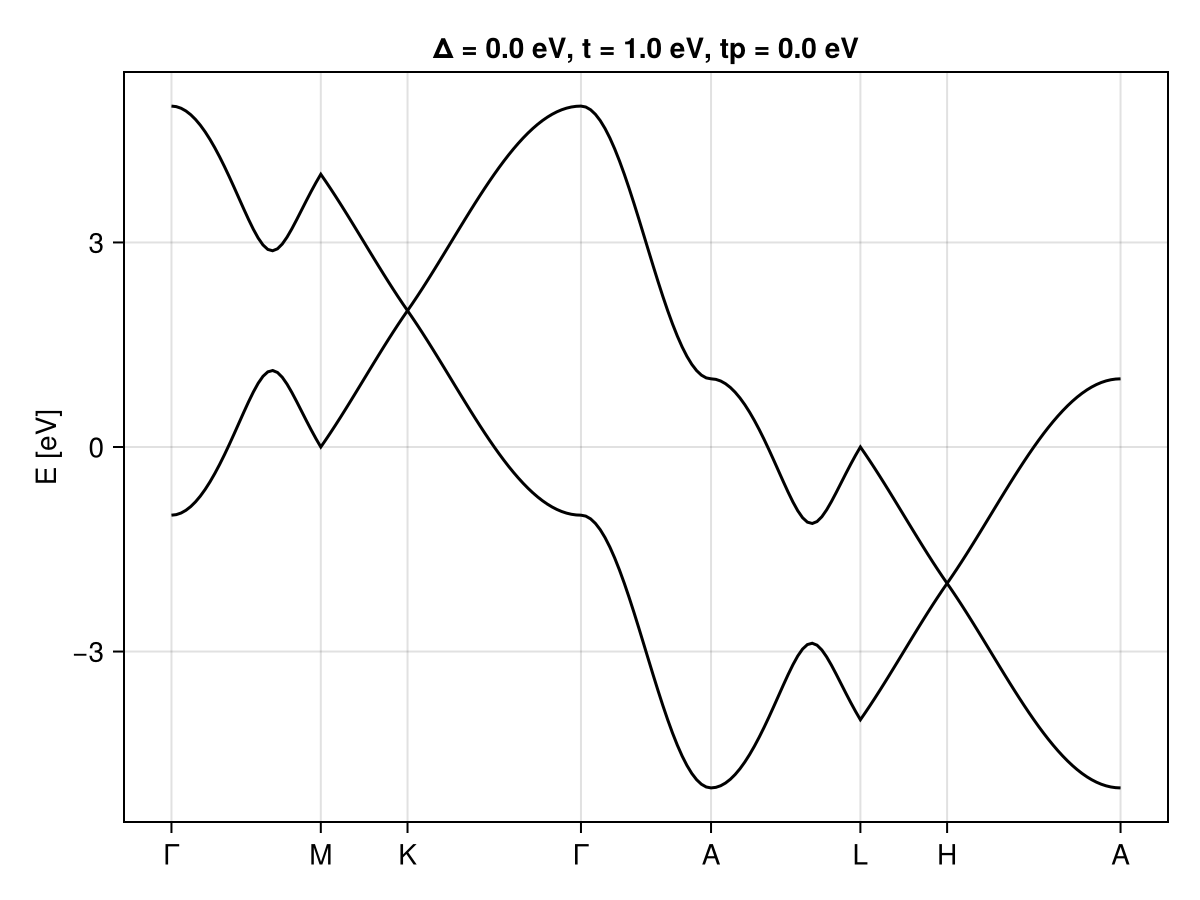

In [6]:
bands_ferroaxial( modelpresets_FA(; μ =0, t =1 ,tp =0, Δ = 0))

## Calculations

In [7]:
evals = 400
mu = 2.5
murange = collect(-3:0.5:3)
xbounds = [-0.5,-0.5, -0.5]
T = 100

kws = (dirj = :x, dirE = :z, dirB = :x, T = T,
    evals = evals, integration_method = :uniform_grid, fermi_surface = false, botbounds =xbounds, 
    topbounds = -xbounds, omega_MM_switch = false, PS_switch = true, QM_switch = true)
#_________________________________________________________________________________________



(dirj = :x, dirE = :z, dirB = :x, T = 100, evals = 400, integration_method = :uniform_grid, fermi_surface = false, botbounds = [-0.5, -0.5, -0.5], topbounds = [0.5, 0.5, 0.5], omega_MM_switch = false, PS_switch = true, QM_switch = true)

In [8]:
p = modelpresets_FA(; μ = 4, t = 1 ,tp = 1, Δ = 2)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...)


Quantum_correction_σijk_antisym{StaticArraysCore.SVector{3, Vector{Float64}}, Field_Induced_Hall_Effect.var"#h#55"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dh#59"{Field_Induced_Hall_Effect.var"#dhz#58"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhy#57"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhx#56"{FerroAxialHam}}, Field_Induced_Hall_Effect.var"#ddh#61"{Field_Induced_Hall_Effect.var"#didjh#60"{FerroAxialHam}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol z
  dirB: Symbol x
  h: h (function of type Field_Induced_Hall_Effect.var"#h#55"{FerroAxialHam})
  nabla_h: dh (function of type Field_Induced_Hall_Effect.var"#dh#59"{Field_Induced_Hall_Effect.var"#dhz#58"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhy#57"{FerroAxialHam}, Field_Induced_Hall_Effect.var"#dhx#56"{FerroAxialHam}})
  nabla_nabla_h: ddh (function of type Field_Induced_Hall_Effect.var"#ddh#61"{Field_Induced_Hall_Effect.var"#didjh#60"{FerroAxialHam}})
  gs: StaticArraysCore.SVector{3, Vector{Float64}

In [9]:
σ_ijk_A1_qc =  quantum_contribution(comp_pres) #22.1 #15 # 17

Uniform integration
3


5.535272277818229e-13

## K - resolved quantities

In [18]:
using Brillouin, Bravais, BZpaths

In [16]:
function k_mesh_evals(quantity, p, R1, R2, R3, c_symb::Symbol; u0 = 0,  botbounds = [-0.5,-0.5], topbounds = [0.5,0.5], kpoints = 100)
    Gs = dualbasis([R1,R2,R3])
    N = floor(Int, kpoints^(1/3))
    uas = range(botbounds[1], topbounds[1], length=N)
    ubs = range(botbounds[2], topbounds[2], length=N)
    c = Optics_in_the_length_gauge.symb_to_ind(c_symb)
    u_param(ua,ub, c) = ifelse(c == 1, [u0,ua,ub], ifelse(c == 2, [ua,u0,ub], [ua,ub,u0]))
    aux_f(ua,ub,c) = Optics_in_the_length_gauge.transform_k(SVector(ua,ub,c), Gs)
    a, b = setdiff(1:3, [c])
    ka = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[a] for ua in uas, ub in ubs]
    kb = [Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c), Gs)[b] for ua in uas, ub in ubs]
    f(ua,ub) = quantity(p, Optics_in_the_length_gauge.transform_k(u_param(ua,ub,c),Gs))
    Z = [f(ua,ub) for ua in uas, ub in ubs]
    return (a,b), ka, kb, Z
end

function plot_kresolved(kx, ky, Z, u0; label = "f(a, b)", titlelab = "")
    fig = Figure(size = (600, 500))
    ax = Axis(fig[1, 1], xlabel="ka [1/Å]", ylabel="kb [1/Å]", title = titlelab * ", uz = $(u0)")
    cmap = :RdBu#reverse(cgrad(:grays))  # CairoMakie built-in colormap, light-to-dark blues
    hm = surface!(ax, kx, ky, zeros(size(Z)),
                color=Z,
                shading=NoShading,
                colormap=cmap,
                colorrange=(-maximum(abs,Z), maximum(abs,Z)))
    Colorbar(fig[1, 2], hm, label=label)
    # ylims!(ax, -2π-π/2, 2π+π/2)
    fig
end

plot_kresolved (generic function with 1 method)

### Density of states

In [5]:
# compute k mesh


T = 10 
u0 = 0.01 # kz

a = 1.0
Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2, 0], a .* [0,0,1])
R1 = Rs[1]
R2 = Rs[2]
R3 = Rs[3]

kws = (T = T, fermi_surface = true)

p = modelpresets_FA(; μ = 0, t = 1 ,tp = 0, Δ = 0)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);


In [28]:
# compute k mesh
dirs, kx, ky, Z = k_mesh_evals(Optics_in_the_length_gauge.integrand_quantum_contribution_q, 
    comp_pres, R1, R2, R3, :z, u0 =u0, botbounds = 2.2 .* [-0.5,-0.5], topbounds = 2.2 .* [0.5,0.5], kpoints = 500000);

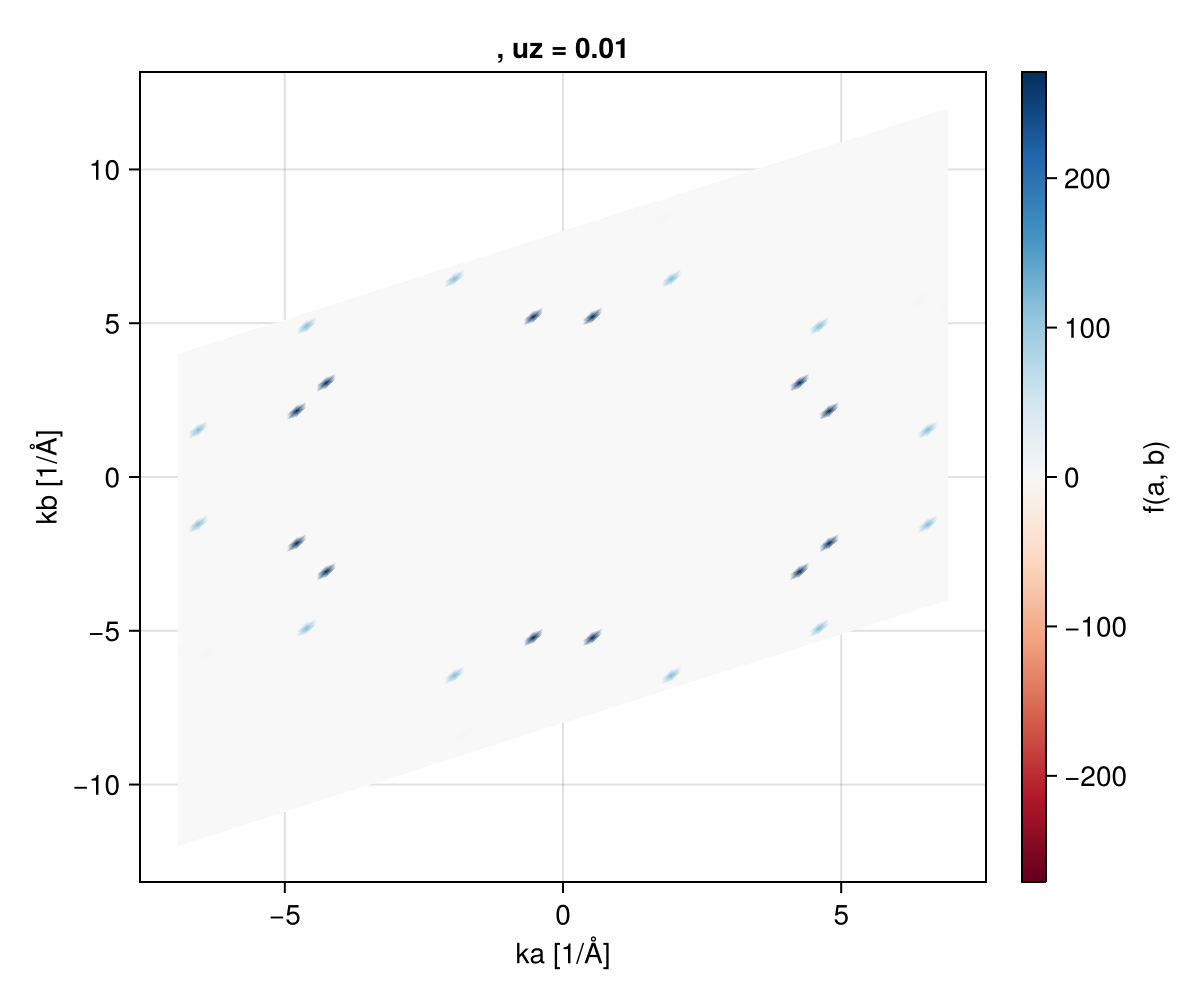

In [21]:
plot_kresolved(kx,ky,Z, u0) 

### F

In [42]:
# compute k mesh

T = 1
u0 = 0.0000

kws = (dirj = :x, dirE = :y, dirB = :z, T = T, fermi_surface = false, omega_MM_switch = false, PS_switch = true, QM_switch = true)

p = modelpresets_FA(; μ = 0, t = 1 ,tp = 0.5, Δ = 0.5)
comp_pres = sigma_abc_ferroaxial_wrapper_3d(p; kws...);



In [43]:
# compute k mesh
Fab(q) = Optics_in_the_length_gauge.F(comp_pres, q, :x, :y)
dirs, kx, ky, Z = k_mesh_evals(Optics_in_the_length_gauge.integrand_quantum_contribution_q, 
    comp_pres, R1, R2, R3, :z, u0 =u0, botbounds = 2.2 .* [-0.5,-0.5], topbounds = 2.2 .* [0.5,0.5], kpoints = 4000000);

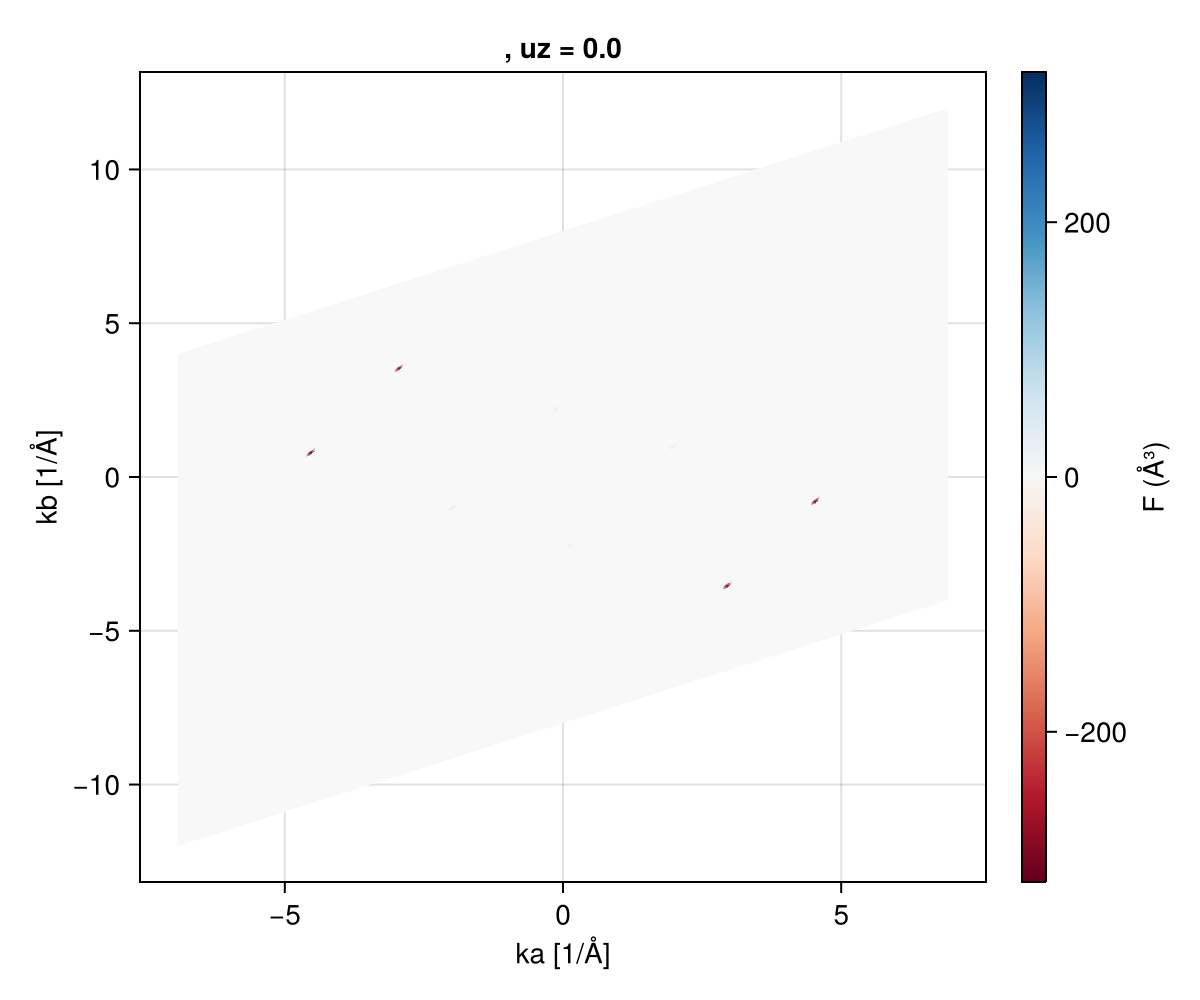

In [44]:
plot_kresolved(kx,ky,Z, u0, label = "F (Å³)") 